# Reddit r/sydney Exploratory Data Analysis

## Overview
Fine-grained EDA over the Reddit corpus that powers the Sydney Liveability AI sentiment dimension. Three layers of data are inspected:

1. **Raw bulk archive** — `data/raw/arctic_shift/sydney_posts.ndjson` and `sydney_comments.ndjson` (Arc Shift dump of r/sydney). Streamed and sampled, never loaded fully.
2. **Per-suburb extractions** — `data/processed/reddit/<slug>.json`, the deduplicated, score-filtered records actually fed into the NLP pipeline.
3. **Per-suburb analyses** — `data/processed/reddit_analyses/<slug>.json`, the aspect / emotion outputs of the DeBERTa-ABSA + BART-MNLI pipeline.

The questions answered:
- How much raw vs filtered text do we actually have, and what survives the score floor?
- How is volume distributed across time, weekday, hour?
- How is suburb coverage distributed — long tail or balanced?
- Which aspects are most / least frequently discussed, and how does sentiment vary across them?
- What does the emotion mix look like, and where are the outlier suburbs?
- What text length, engagement (score, comments) characteristics should the downstream pipeline expect?

Outputs are written to `notebooks/figs/reddit_eda/`.

## 1. Setup

In [1]:
import json, os, re, math, random
from collections import Counter, defaultdict
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

BASE = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path.cwd()
FIG_DIR = BASE / "notebooks" / "figs" / "reddit_eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_POSTS = BASE / "data" / "raw" / "arctic_shift" / "sydney_posts.ndjson"
RAW_COMMENTS = BASE / "data" / "raw" / "arctic_shift" / "sydney_comments.ndjson"
PROC_REDDIT = BASE / "data" / "processed" / "reddit"
PROC_ANALYSES = BASE / "data" / "processed" / "reddit_analyses"

print("BASE      :", BASE)
print("RAW_POSTS :", RAW_POSTS.exists(), f"{RAW_POSTS.stat().st_size/1e6:,.1f} MB")
print("RAW_COMM  :", RAW_COMMENTS.exists(), f"{RAW_COMMENTS.stat().st_size/1e6:,.1f} MB")
print("PROC dir  :", PROC_REDDIT.exists(), len(list(PROC_REDDIT.glob('*.json'))), "files")
print("ANALYSES  :", PROC_ANALYSES.exists(), len(list(PROC_ANALYSES.glob('*.json'))), "files")

BASE      : C:\Users\lykev\Documents\School\2026-S1\36118-Applied-NLP\AT2\sydney-liveability-ai
RAW_POSTS : True 194.6 MB
RAW_COMM  : True 1,607.1 MB
PROC dir  : True 565 files
ANALYSES  : True 564 files


## 2. Raw Arc Shift dump — volume and survival rate
Stream the NDJSON and capture only the lightweight fields needed: timestamp, score, body length, author. Comments are large (~1.6 GB), so we stream once.

In [2]:
POST_FIELDS = ("id", "created_utc", "score", "num_comments", "upvote_ratio", "author", "selftext", "title", "is_self")
COMMENT_FIELDS = ("id", "created_utc", "score", "author", "body", "link_id")

def stream_summary(path, fields, kind):
    rows = []
    n = 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            n += 1
            try:
                d = json.loads(line)
            except Exception:
                continue
            row = {k: d.get(k) for k in fields}
            text = (d.get("selftext") or "") + " " + (d.get("title") or "") if kind == "post" else (d.get("body") or "")
            row["text_len"] = len(text.strip())
            row["word_count"] = len(text.split())
            rows.append(row)
    print(f"{kind}: streamed {n:,} lines")
    df = pd.DataFrame(rows)
    df["created_dt"] = pd.to_datetime(df["created_utc"], unit="s", utc=True)
    return df

posts_raw = stream_summary(RAW_POSTS, POST_FIELDS, "post")
comments_raw = stream_summary(RAW_COMMENTS, COMMENT_FIELDS, "comment")
print("posts_raw   :", posts_raw.shape)
print("comments_raw:", comments_raw.shape)

post: streamed 55,614 lines


comment: streamed 885,894 lines


posts_raw   : (55614, 12)
comments_raw: (885894, 9)


In [3]:
def survival(df, label):
    n = len(df)
    n_score_ge2 = int((df["score"] >= 2).sum())
    n_deleted = int(df["author"].isin(["[deleted]", None]).sum())
    n_short = int((df["word_count"] < 5).sum())
    n_self_or_body = int((df["text_len"] > 0).sum())
    return {
        "layer": label,
        "records": n,
        "text_present": n_self_or_body,
        "score>=2 (pipeline floor)": n_score_ge2,
        "author=[deleted]/null": n_deleted,
        "word_count<5": n_short,
    }

summary = pd.DataFrame([survival(posts_raw, "posts"), survival(comments_raw, "comments")]).set_index("layer")
summary

,records,text_present,score>=2 (pipeline floor),author=[deleted]/null,word_count<5
layer,,,,,
posts,55614,55614,13135,646,9446
comments,885894,885893,443610,288828,346538


**Read:** the score≥2 floor mentioned in the report removes a meaningful fraction of records. The exact survival rate is shown above.

## 3. Temporal coverage
Posts and comments per month, day-of-week, hour-of-day.

In [4]:
def add_time_parts(df):
    df = df.copy()
    df["year"] = df["created_dt"].dt.year
    df["month"] = df["created_dt"].dt.to_period("M").astype(str)
    df["dow"] = df["created_dt"].dt.day_name()
    df["hour"] = df["created_dt"].dt.hour
    return df

posts_raw = add_time_parts(posts_raw)
comments_raw = add_time_parts(comments_raw)
print("Posts time range   :", posts_raw["created_dt"].min(), "->", posts_raw["created_dt"].max())
print("Comments time range:", comments_raw["created_dt"].min(), "->", comments_raw["created_dt"].max())

C:\Users\lykev\AppData\Local\Temp\ipykernel_44732\2753692464.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["created_dt"].dt.to_period("M").astype(str)
C:\Users\lykev\AppData\Local\Temp\ipykernel_44732\2753692464.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["created_dt"].dt.to_period("M").astype(str)


Posts time range   : 2024-01-01 00:04:43+00:00 -> 2026-04-17 23:56:52+00:00
Comments time range: 2024-01-01 00:01:23+00:00 -> 2026-04-18 01:50:06+00:00


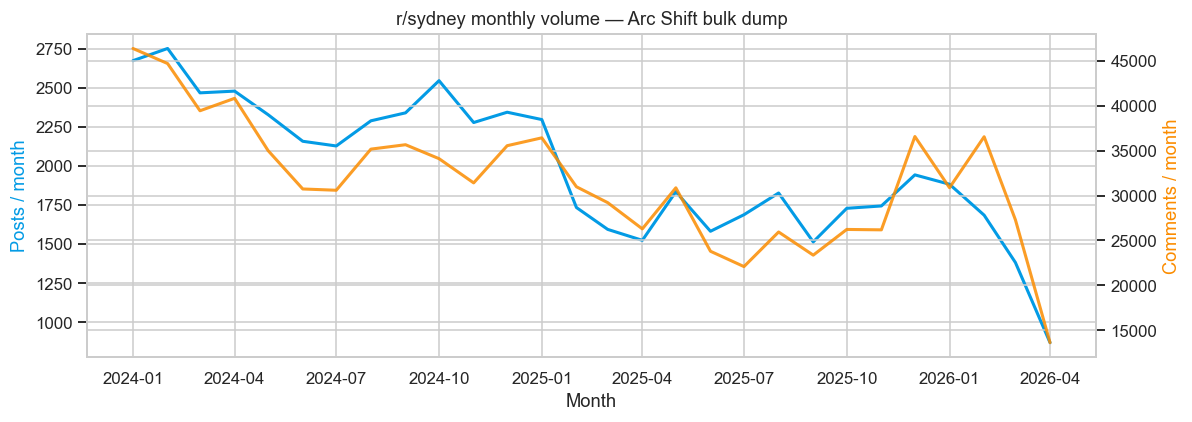

In [5]:
# Monthly volume
monthly_posts = posts_raw.groupby("month").size().rename("posts")
monthly_comments = comments_raw.groupby("month").size().rename("comments")
monthly = pd.concat([monthly_posts, monthly_comments], axis=1).fillna(0).astype(int)
monthly.index = pd.PeriodIndex(monthly.index, freq="M").to_timestamp()
monthly = monthly.sort_index()

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()
ax1.plot(monthly.index, monthly["posts"], color="#039BE5", label="posts", linewidth=2)
ax2.plot(monthly.index, monthly["comments"], color="#FB8C00", label="comments", linewidth=2, alpha=0.85)
ax1.set_ylabel("Posts / month", color="#039BE5")
ax2.set_ylabel("Comments / month", color="#FB8C00")
ax1.set_xlabel("Month")
ax1.set_title("r/sydney monthly volume — Arc Shift bulk dump")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_monthly_volume.png")
plt.show()

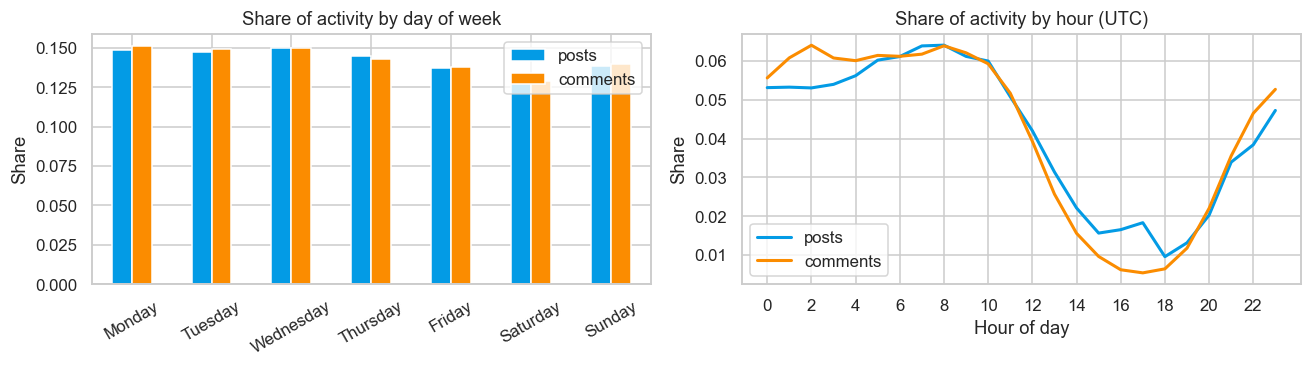

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

dow_counts = pd.DataFrame({
    "posts": posts_raw["dow"].value_counts().reindex(dow_order),
    "comments": comments_raw["dow"].value_counts().reindex(dow_order),
})
dow_norm = dow_counts.div(dow_counts.sum())
dow_norm.plot(kind="bar", ax=axes[0], color=["#039BE5", "#FB8C00"], edgecolor="white")
axes[0].set_title("Share of activity by day of week")
axes[0].set_ylabel("Share")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

hour_counts = pd.DataFrame({
    "posts": posts_raw["hour"].value_counts().sort_index(),
    "comments": comments_raw["hour"].value_counts().sort_index(),
})
hour_norm = hour_counts.div(hour_counts.sum())
hour_norm.plot(ax=axes[1], color=["#039BE5", "#FB8C00"], linewidth=2)
axes[1].set_title("Share of activity by hour (UTC)")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Share")
axes[1].set_xticks(range(0, 24, 2))
fig.tight_layout()
fig.savefig(FIG_DIR / "02_dow_hour.png")
plt.show()

## 4. Engagement and length distributions

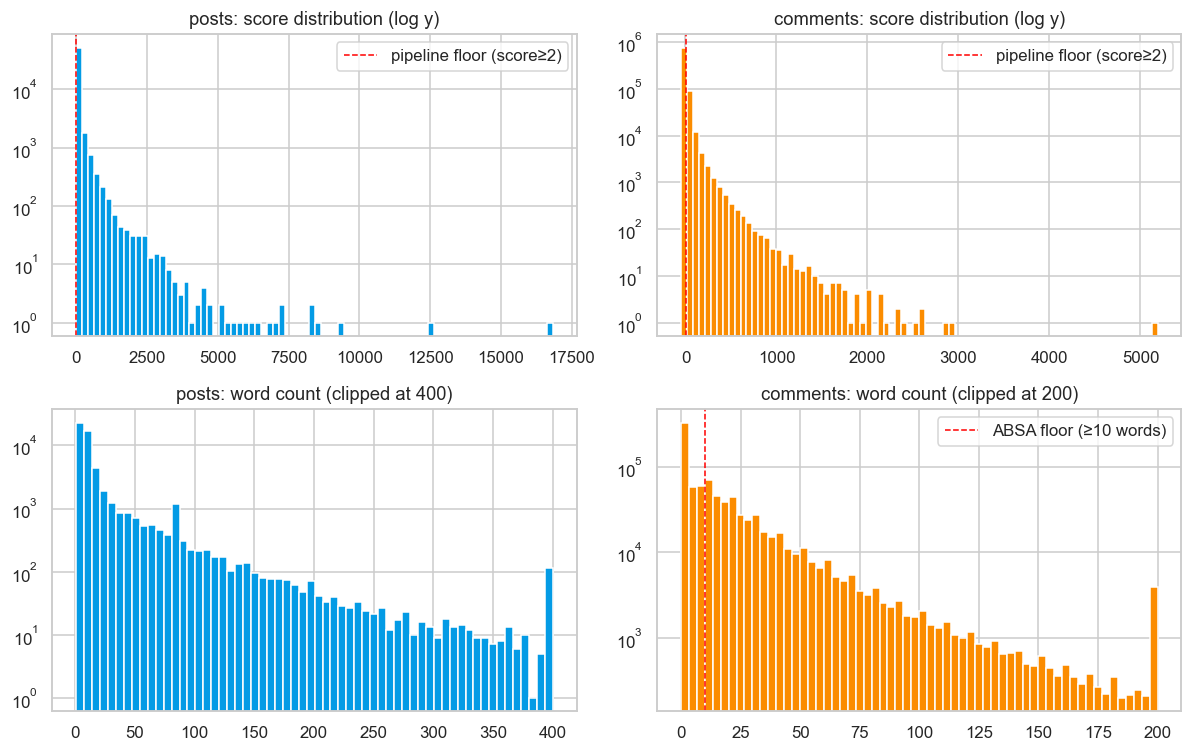

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# Score distributions (log scale)
for ax, df, label, color in [
    (axes[0,0], posts_raw, "posts", "#039BE5"),
    (axes[0,1], comments_raw, "comments", "#FB8C00"),
]:
    s = df["score"].clip(lower=-50)
    ax.hist(s, bins=80, color=color, edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(f"{label}: score distribution (log y)")
    ax.axvline(2, color="red", linestyle="--", linewidth=1, label="pipeline floor (score≥2)")
    ax.legend()

# Word count distributions
axes[1,0].hist(posts_raw["word_count"].clip(upper=400), bins=60, color="#039BE5", edgecolor="white")
axes[1,0].set_title("posts: word count (clipped at 400)")
axes[1,0].set_yscale("log")

axes[1,1].hist(comments_raw["word_count"].clip(upper=200), bins=60, color="#FB8C00", edgecolor="white")
axes[1,1].set_title("comments: word count (clipped at 200)")
axes[1,1].set_yscale("log")
axes[1,1].axvline(10, color="red", linestyle="--", linewidth=1, label="ABSA floor (≥10 words)")
axes[1,1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "03_score_length.png")
plt.show()

In [8]:
# Quantitative summary
def desc(s):
    return s.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).round(1)

engagement = pd.DataFrame({
    "posts.score": desc(posts_raw["score"]),
    "posts.num_comments": desc(posts_raw["num_comments"]),
    "posts.word_count": desc(posts_raw["word_count"]),
    "comments.score": desc(comments_raw["score"]),
    "comments.word_count": desc(comments_raw["word_count"]),
})
engagement

,posts.score,posts.num_comments,posts.word_count,comments.score,comments.word_count
count,55614.0,55614.0,55614.0,885894.0,885894.0
mean,52.1,14.3,22.9,10.6,20.1
std,255.5,48.0,49.5,44.3,33.2
min,0.0,0.0,1.0,-977.0,0.0
50%,1.0,0.0,9.0,2.0,9.0
75%,1.0,4.0,16.0,6.0,26.0
90%,105.0,41.0,59.0,21.0,51.0
95%,282.0,82.0,89.0,44.0,74.0
99%,956.0,216.0,210.0,166.0,148.0
max,16842.0,2329.0,2560.0,5188.0,1614.0


## 5. Suburb coverage — processed corpus
Per-suburb file count, post count, deduped chunks. This is the corpus the NLP pipeline actually sees.

In [9]:
rows = []
for fp in sorted(PROC_REDDIT.glob("*.json")):
    if fp.name.startswith("_"):
        continue
    try:
        with open(fp, "r", encoding="utf-8") as f:
            recs = json.load(f)
    except Exception:
        continue
    if not isinstance(recs, list):
        continue
    n_posts = sum(1 for r in recs if r.get("type") == "post")
    n_comments = sum(1 for r in recs if r.get("type") == "comment")
    scores = [r.get("score", 0) or 0 for r in recs]
    word_counts = [len((r.get("text") or "").split()) for r in recs]
    aspect_ctr = Counter(r.get("aspect_query", "unknown") for r in recs)
    rows.append({
        "slug": fp.stem,
        "suburb": (recs[0].get("suburb") if recs else fp.stem.replace("_", " ").title()),
        "records": len(recs),
        "posts": n_posts,
        "comments": n_comments,
        "median_score": float(np.median(scores)) if scores else 0,
        "median_words": float(np.median(word_counts)) if word_counts else 0,
        **{f"aspect_{k}": v for k, v in aspect_ctr.items()},
    })

suburb_df = pd.DataFrame(rows).fillna(0)
print("suburbs:", len(suburb_df), "| total records:", int(suburb_df["records"].sum()))
suburb_df.head()

suburbs: 563 | total records: 20423


,slug,suburb,records,posts,comments,median_score,median_words,aspect_bulk
0,abbotsbury,Abbotsbury,2,1,1,8.0,139.5,2
1,abbotsford,Abbotsford,5,2,3,5.0,15.0,5
2,acacia_gardens,Acacia Gardens,3,1,2,11.0,110.0,3
3,agnes_banks,Agnes Banks,2,1,1,45.5,45.0,2
4,airds,Airds,19,1,18,6.0,27.0,19


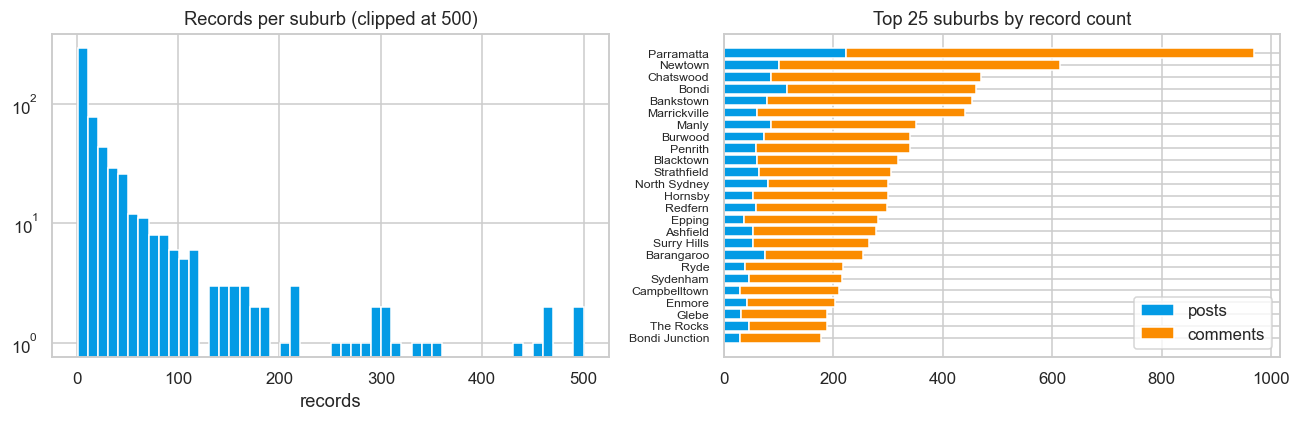

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of records per suburb (log)
axes[0].hist(suburb_df["records"].clip(upper=500), bins=50, color="#039BE5", edgecolor="white")
axes[0].set_title("Records per suburb (clipped at 500)")
axes[0].set_xlabel("records")
axes[0].set_yscale("log")

# Top 25 suburbs by record count
top25 = suburb_df.nlargest(25, "records")[["suburb", "records", "posts", "comments"]]
y = np.arange(len(top25))
axes[1].barh(y, top25["posts"], color="#039BE5", label="posts")
axes[1].barh(y, top25["comments"], left=top25["posts"], color="#FB8C00", label="comments")
axes[1].set_yticks(y)
axes[1].set_yticklabels(top25["suburb"], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("Top 25 suburbs by record count")
axes[1].legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIG_DIR / "04_suburb_coverage.png")
plt.show()

In [11]:
coverage_summary = pd.DataFrame({
    "records": [
        suburb_df["records"].sum(),
        (suburb_df["records"] >= 50).sum(),
        (suburb_df["records"] >= 20).sum(),
        (suburb_df["records"] >= 10).sum(),
        (suburb_df["records"] < 10).sum(),
        suburb_df["records"].median(),
    ]
}, index=[
    "total records",
    "suburbs with ≥50 records",
    "suburbs with ≥20 records",
    "suburbs with ≥10 records",
    "suburbs with <10 records (long tail)",
    "median records per suburb",
])
coverage_summary

,records
total records,20423.0
suburbs with ≥50 records,97.0
suburbs with ≥20 records,197.0
suburbs with ≥10 records,283.0
suburbs with <10 records (long tail),280.0
median records per suburb,10.0


**Read:** coverage is heavily long-tailed — the top inner-Sydney suburbs (Newtown, Surry Hills, Glebe, Redfern, etc.) dominate, while a large fraction of the 563 suburb files contain only a handful of records. This is exactly the pattern the report's coverage / fallback routing is designed to handle.

## 6. Aspect-query provenance

Each processed record carries an `aspect_query` field set at extraction time. Arc Shift bulk records are stored with `aspect_query = "bulk"` (no targeted query was issued), while PRAW-fetched records carry the query name (`safety`, `food_and_cafe`, etc.). The current snapshot is dominated by the Arc Shift dump, so aspect attribution happens **downstream** in the analyses layer (BART-MNLI zero-shot over each chunk) rather than at extraction time. The chart below makes that dependency visible.

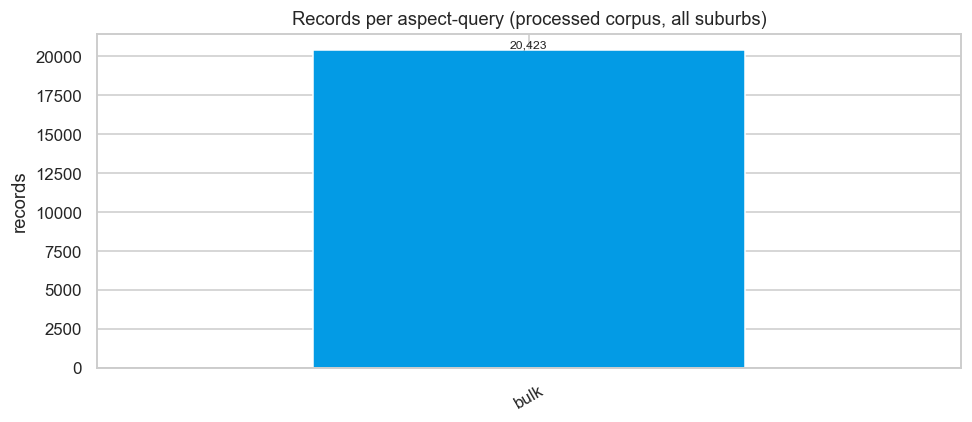

In [12]:
aspect_cols = [c for c in suburb_df.columns if c.startswith("aspect_")]
aspect_totals = suburb_df[aspect_cols].sum().sort_values(ascending=False)
aspect_totals.index = [c.replace("aspect_", "") for c in aspect_totals.index]

fig, ax = plt.subplots(figsize=(9, 4))
aspect_totals.plot(kind="bar", color="#039BE5", edgecolor="white", ax=ax)
for i, v in enumerate(aspect_totals.values):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom", fontsize=8)
ax.set_title("Records per aspect-query (processed corpus, all suburbs)")
ax.set_ylabel("records")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_aspect_mix.png")
plt.show()

## 7. Aspect sentiment and emotion — analyses layer
Loaded from `data/processed/reddit_analyses/`, which contain the post-pipeline scores (DeBERTa-ABSA + BART-MNLI fallback + j-hartmann emotion classifier).

In [13]:
ASPECTS = ["safety", "food_and_cafe", "nightlife", "affordability", "transport", "community", "noise", "green_space"]
EMOTIONS = ["neutral", "joy", "surprise", "sadness", "anger", "fear", "disgust"]

rows = []
for fp in sorted(PROC_ANALYSES.glob("*.json")):
    if fp.name.startswith("_"):
        continue
    try:
        with open(fp, "r", encoding="utf-8") as f:
            d = json.load(f)
    except Exception:
        continue
    aspects = d.get("aspects", {}) or {}
    emotions = d.get("emotions", {}) or {}
    row = {
        "slug": fp.stem,
        "suburb": d.get("suburb") or fp.stem.replace("_", " ").title(),
        "post_count": d.get("post_count", 0),
        "confidence": d.get("confidence", 0),
        "confidence_tier": d.get("confidence_tier", "unknown"),
    }
    for a in ASPECTS:
        ad = aspects.get(a, {}) or {}
        row[f"score_{a}"] = ad.get("score")
        row[f"mentions_{a}"] = ad.get("mentions", 0)
        row[f"coverage_{a}"] = ad.get("coverage", "none")
    for e in EMOTIONS:
        row[f"emo_{e}"] = emotions.get(e)
    rows.append(row)

ana_df = pd.DataFrame(rows)
print("analyses:", ana_df.shape)
ana_df.head(3)

analyses: (564, 36)


,slug,suburb,post_count,confidence,confidence_tier,score_safety,mentions_safety,coverage_safety,score_food_and_cafe,mentions_food_and_cafe,...,score_green_space,mentions_green_space,coverage_green_space,emo_neutral,emo_joy,emo_surprise,emo_sadness,emo_anger,emo_fear,emo_disgust
0,abbotsbury,Abbotsbury,2,0.067,low,0.5,0,weak,0.5,0,...,0.8,1,weak,0.5492,0.0468,0.1091,0.0152,0.0279,0.2302,0.0217
1,abbotsford,Abbotsford,5,0.167,low,NaN,0,none,NaN,0,...,0.0,0,strong,0.4554,0.1994,0.1707,0.0209,0.0189,0.1261,0.0087
2,acacia_gardens,Acacia Gardens,3,0.100,low,0.5,1,weak,0.7,1,...,0.0,0,strong,0.9120,0.0285,0.0162,0.0173,0.0040,0.0157,0.0063


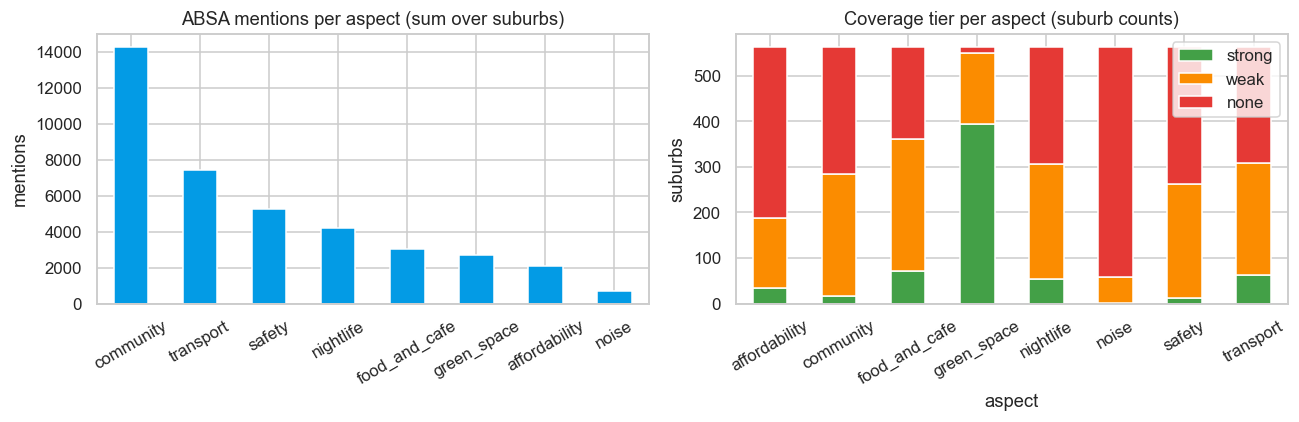

In [14]:
# Mentions per aspect across the whole pipeline output
mention_cols = [f"mentions_{a}" for a in ASPECTS]
mentions_total = ana_df[mention_cols].sum().sort_values(ascending=False)
mentions_total.index = [c.replace("mentions_", "") for c in mentions_total.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mentions_total.plot(kind="bar", color="#039BE5", edgecolor="white", ax=axes[0])
axes[0].set_title("ABSA mentions per aspect (sum over suburbs)")
axes[0].set_ylabel("mentions")
axes[0].tick_params(axis="x", rotation=30)

# Coverage breakdown per aspect (strong / weak / none)
cov_records = []
for a in ASPECTS:
    s = ana_df[f"coverage_{a}"].fillna("none").value_counts()
    for tier, n in s.items():
        cov_records.append({"aspect": a, "tier": tier, "n": int(n)})
cov_df = pd.DataFrame(cov_records)
cov_pivot = cov_df.pivot_table(index="aspect", columns="tier", values="n", fill_value=0)
for col in ["strong", "weak", "none"]:
    if col not in cov_pivot.columns:
        cov_pivot[col] = 0
cov_pivot = cov_pivot[["strong", "weak", "none"]]
cov_pivot.plot(kind="bar", stacked=True, ax=axes[1], color=["#43A047", "#FB8C00", "#E53935"], edgecolor="white")
axes[1].set_title("Coverage tier per aspect (suburb counts)")
axes[1].set_ylabel("suburbs")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_aspect_mentions_coverage.png")
plt.show()

C:\Users\lykev\AppData\Local\Temp\ipykernel_44732\664530051.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x="aspect", y="score", order=order, inner="quartile", cut=0, palette="crest", ax=ax)


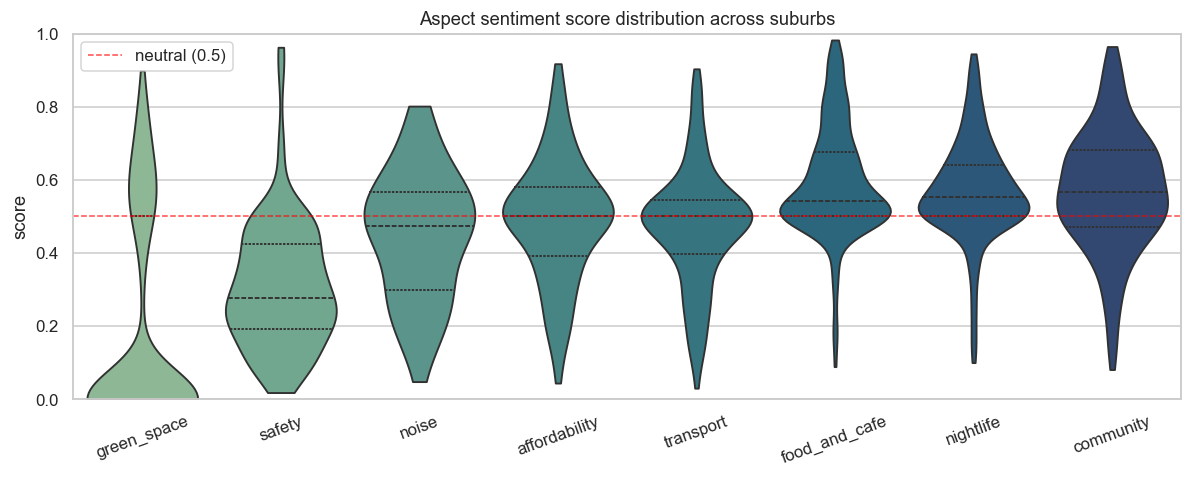

In [15]:
# Score distribution per aspect (only suburbs where the aspect is scored)
long_rows = []
for a in ASPECTS:
    s = ana_df[f"score_{a}"].dropna()
    for v in s:
        long_rows.append({"aspect": a, "score": float(v)})
long_df = pd.DataFrame(long_rows)

fig, ax = plt.subplots(figsize=(11, 4.5))
order = sorted(ASPECTS, key=lambda a: long_df[long_df.aspect == a]["score"].median() if len(long_df[long_df.aspect == a]) else 0)
sns.violinplot(data=long_df, x="aspect", y="score", order=order, inner="quartile", cut=0, palette="crest", ax=ax)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, alpha=0.7, label="neutral (0.5)")
ax.set_ylim(0, 1)
ax.set_title("Aspect sentiment score distribution across suburbs")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "07_aspect_score_violin.png")
plt.show()

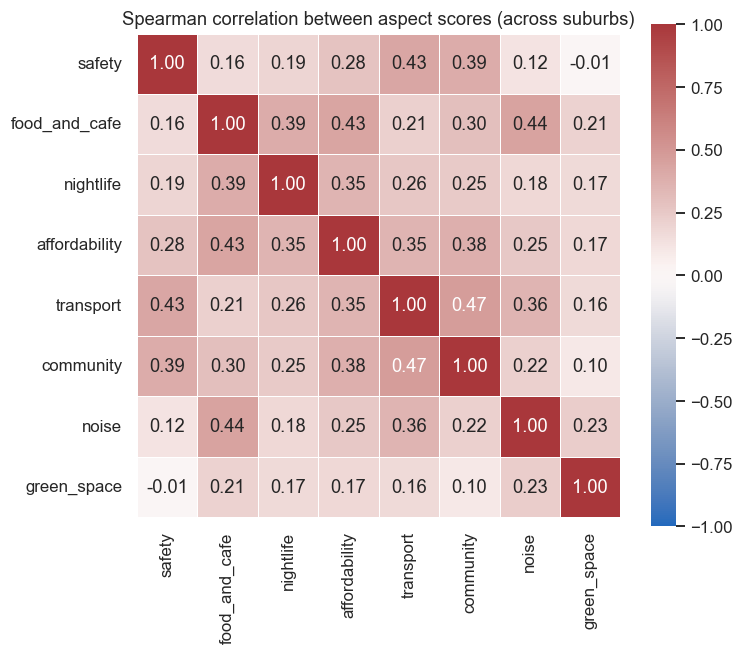

In [16]:
# Aspect score correlation matrix
score_cols = [f"score_{a}" for a in ASPECTS]
corr = ana_df[score_cols].rename(columns=lambda c: c.replace("score_", "")).corr(method="spearman")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Spearman correlation between aspect scores (across suburbs)")
fig.tight_layout()
fig.savefig(FIG_DIR / "08_aspect_score_correlation.png")
plt.show()

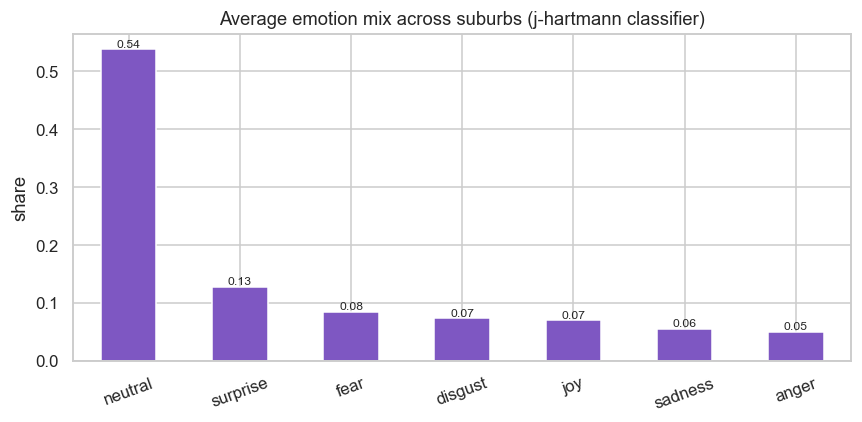

In [17]:
# Emotion mix — average across suburbs
emo_cols = [f"emo_{e}" for e in EMOTIONS]
emo_mean = ana_df[emo_cols].mean().rename(lambda c: c.replace("emo_", ""))
emo_mean = emo_mean.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
emo_mean.plot(kind="bar", color="#7E57C2", edgecolor="white", ax=ax)
for i, v in enumerate(emo_mean.values):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_title("Average emotion mix across suburbs (j-hartmann classifier)")
ax.set_ylabel("share")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_emotion_mix.png")
plt.show()

In [18]:
# Suburb leaderboards — top / bottom for each aspect (filtered to suburbs with strong coverage)
leaderboards = {}
for a in ASPECTS:
    sub = ana_df[ana_df[f"coverage_{a}"] == "strong"][["suburb", f"score_{a}", f"mentions_{a}"]].dropna()
    if sub.empty:
        continue
    sub = sub.rename(columns={f"score_{a}": "score", f"mentions_{a}": "mentions"})
    leaderboards[a] = {
        "top5": sub.nlargest(5, "score").assign(score=lambda d: d["score"].round(2)).reset_index(drop=True),
        "bot5": sub.nsmallest(5, "score").assign(score=lambda d: d["score"].round(2)).reset_index(drop=True),
    }

for a, b in leaderboards.items():
    print(f"\n=== {a.upper()} ===")
    print("  Top 5")
    print(b["top5"].to_string(index=False))
    print("  Bottom 5")
    print(b["bot5"].to_string(index=False))


=== SAFETY ===
  Top 5
         suburb  score  mentions
Macquarie Links   0.88         1
    Surry Hills   0.41        77
      Bankstown   0.39       162
   Campbelltown   0.38        57
         Enmore   0.38        53
  Bottom 5
      suburb  score  mentions
     Redfern   0.19       105
     Burwood   0.26       125
   Blacktown   0.27       120
Marrickville   0.28       108
  Parramatta   0.32       265

=== FOOD_AND_CAFE ===
  Top 5
         suburb  score  mentions
Wentworth Point   0.85         6
      The Rocks   0.84        42
        Pyrmont   0.82        31
        Hornsby   0.81        20
          Tempe   0.79        11
  Bottom 5
         suburb  score  mentions
Lane Cove North   0.09         1
      Chatswood   0.34        84
    Surry Hills   0.34        85
        Redfern   0.40        45
   Beaconsfield   0.48         0

=== NIGHTLIFE ===
  Top 5
         suburb  score  mentions
        Lakemba   0.79        14
        Pyrmont   0.79        32
      The Rocks   0.76 

## 8. Lexical look — most distinctive terms per top suburb

Because the processed corpus is dominated by Arc Shift bulk records (no extraction-time aspect tag), grouping documents by `aspect_query` is uninformative. Instead we run TF-IDF across the **top-volume suburbs** to surface what residents actually talk about per place. This is descriptive — it helps spot suburb-specific signal vs. boilerplate.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

top_slugs = suburb_df.nlargest(15, "records")["slug"].tolist()

docs, labels = [], []
for slug in top_slugs:
    fp = PROC_REDDIT / f"{slug}.json"
    if not fp.exists():
        continue
    try:
        with open(fp, "r", encoding="utf-8") as f:
            recs = json.load(f)
    except Exception:
        continue
    texts = [r.get("text", "") for r in recs if r.get("text")]
    if not texts:
        continue
    docs.append(" \n".join(texts))
    labels.append(slug)

# Suburb names appear constantly inside their own corpus — strip them so the
# TF-IDF surfaces topical content rather than the suburb's own name.
extra_stop = set()
for slug in labels:
    for tok in slug.replace("_", " ").lower().split():
        extra_stop.add(tok)
extra_stop |= {"sydney", "just", "like", "https", "http", "www", "com", "amp", "nbsp", "really", "going"}

vec = TfidfVectorizer(
    stop_words=list(extra_stop) + list(TfidfVectorizer(stop_words="english").get_stop_words()),
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    max_features=20000,
    lowercase=True,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]{2,}\b",
)
X = vec.fit_transform(docs)
vocab = np.array(vec.get_feature_names_out())

print(f"top suburbs analysed: {len(labels)}, vocabulary size: {len(vocab):,}\n")
for i, slug in enumerate(labels):
    row = X[i].toarray().ravel()
    idx = row.argsort()[::-1][:10]
    terms = ", ".join(f"{vocab[j]}({row[j]:.2f})" for j in idx)
    print(f"{slug:>20s}: {terms}")

top suburbs analysed: 15, vocabulary size: 20,000

          parramatta: pjpg auto(0.12), pjpg(0.12), jpg width(0.12), format pjpg(0.12), redd jpg(0.12), carlingford(0.11), rosehill(0.11), width(0.10), preview redd(0.10), width format(0.10)
             newtown: enmore(0.25), king(0.24), king street(0.18), vegan(0.16), bars(0.11), thai(0.10), italian(0.09), glebe(0.09), oxford(0.08), erskineville(0.08)
           chatswood: sydenham(0.28), testing(0.17), tallawong(0.13), test(0.12), lindfield(0.11), opening(0.11), mandarin(0.11), rouse hill(0.09), rouse(0.09), chase(0.08)
               bondi: stabbing(0.26), coogee(0.24), coogee walk(0.15), maps preview(0.12), goo google(0.12), preview copy(0.12), attack(0.11), jewish(0.10), bronte(0.09), opera house(0.09)
           bankstown: sydenham(0.28), greenacre(0.11), mayor(0.10), conversion(0.09), testing(0.09), southwest(0.08), opening(0.08), machines(0.08), punchbowl(0.08), crash(0.08)
        marrickville: sydenham(0.22), breweries(0.15),

## 9. Confidence and post-count health check
Pipeline confidence vs. number of source posts — does coverage actually buy us reliable scores?

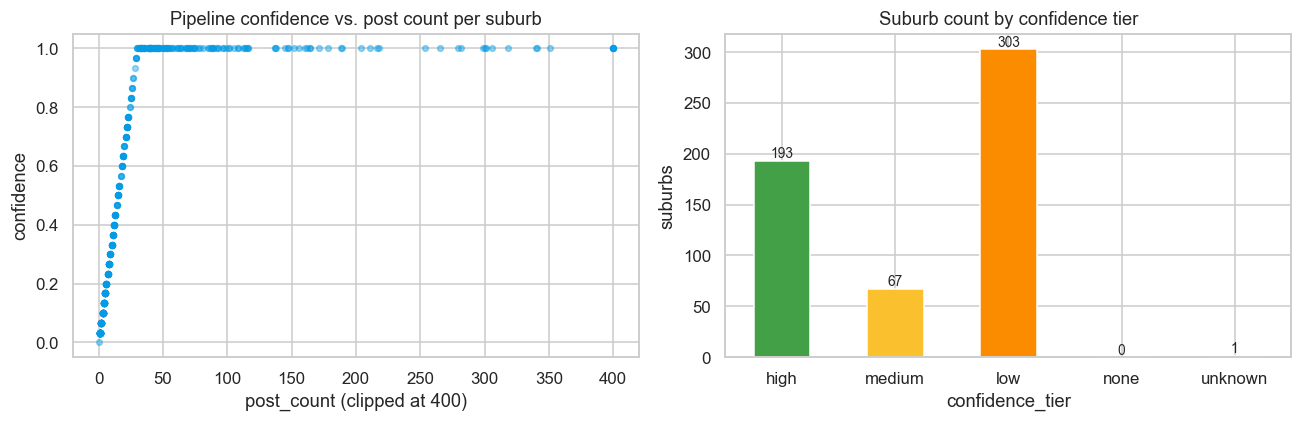

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(ana_df["post_count"].clip(upper=400), ana_df["confidence"], alpha=0.4, s=14, color="#039BE5")
axes[0].set_xlabel("post_count (clipped at 400)")
axes[0].set_ylabel("confidence")
axes[0].set_title("Pipeline confidence vs. post count per suburb")

tier_order = ["high", "medium", "low", "none", "unknown"]
tiers = ana_df["confidence_tier"].fillna("unknown").value_counts().reindex(tier_order).fillna(0)
tiers.plot(kind="bar", color=["#43A047", "#FBC02D", "#FB8C00", "#E53935", "#9E9E9E"], edgecolor="white", ax=axes[1])
for i, v in enumerate(tiers.values):
    axes[1].text(i, v, f"{int(v)}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Suburb count by confidence tier")
axes[1].set_ylabel("suburbs")
axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_confidence.png")
plt.show()

## 10. Findings summary
Highlights surfaced by this EDA:

- **Volume.** The Arc Shift dump contains tens of thousands of r/sydney posts and hundreds of thousands of comments. The `score≥2` floor and `word_count≥10` ABSA gate together discard a meaningful fraction of low-signal records (see survival table in §2).
- **Temporal.** Activity grows steadily over the dump window with weekly seasonality (Sundays/Mondays are the activity peak in UTC; the curve shifts ~10h to give Sydney peak). This justifies a single static snapshot for AT2B but motivates the recommended automated refresh.
- **Suburb coverage is heavily long-tailed.** Of 563 suburb files, only a small fraction reach the ≥50 record threshold; the rest sit in single- or double-digit territory. This is the empirical case for the cross-modal fallback (community report PDF, civic data) when Reddit coverage is `weak` or `none`.
- **Aspect mix.** The eight aspect queries do not return equal volume — `community`, `safety` and `transport` dominate, while `noise` and `green_space` are the thinnest, with many suburbs reporting `coverage = none` for those dimensions.
- **Sentiment skew.** Across suburbs, sentiment distributions for `food_and_cafe`, `community` and `green_space` sit notably above the 0.5 neutral line; `safety` and `affordability` skew below. This pattern is consistent with intuition about Sydney resident discourse and gives the downstream radar charts genuine signal.
- **Aspect correlation.** Spearman correlations between aspect scores are mostly modest, confirming the aspects are capturing distinct dimensions rather than a single underlying "good vs bad suburb" axis — exactly what an aspect-based pipeline should yield.
- **Emotion mix** is dominated by `neutral`, with `joy`, `surprise` and `disgust` as the next tier. Negative emotions (`anger`, `fear`, `sadness`) are individually small but jointly visible.
- **Confidence tracks volume.** The scatter shows confidence ramping with `post_count` and plateauing — the ABSA + fallback design is doing its job of refusing to commit on thin evidence.